## Cosmology: Background and Perturbations for splined DE

* Cubic spline between $w_i$ and $f_i$ at $z_i$, with w(z)=w_n for z>z_n; by construction $f_0=0$.
* change distances: $r_{\rm com}(z)=\int_0^{z} \frac{c \mathrm{d}z'}{H(z')}$
* change linear growth: JaxMGrowth

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
import time

In [3]:
from cloelib.cosmology.splined_wz_cosmology import DESplinedEoSBackground, DESplinedEoSLinearPerturbations, DESplinedEoSNonlinearPerturbations
from cloelib.cosmology.splined_fdez_cosmology import DESplinedDensityBackground, DESplinedDensityLinearPerturbations, DESplinedDensityNonlinearPerturbations


Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


# Cosmology: Background 

## 4 spline-points

In [4]:
w0 = -0.75
wa = -0.86
background_lcdm = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)
background_cpl = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=w0, 
                            wa=wa, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)

In [5]:
from scipy.integrate import quad
from scipy.interpolate import make_interp_spline, CubicSpline
def w_of_z(z, z_i, w_i):
    """
    Returns the equation of state as a function of redshift.

    Outside the knot range, w is held constant at the endpoint values:
    w_i[0] for z < z_i[0] and w_i[-1] for z > z_i[-1].
    """
    z = np.asarray(z)
    #spl_i = make_interp_spline(z_i, w_i)
    spl_i = CubicSpline(z_i, w_i)
    return spl_i(np.clip(z, z_i[0], z_i[-1]))
    #return spl_i(z)

def fde(z, z_i, w_i):
    de_integrand = lambda zp: (1.0 + w_of_z(zp, z_i, w_i)) / (1.0 + zp)
    return np.exp(3.0 * quad(de_integrand, 0.0, float(z))[0])

def w_of_z_cpl(z, w0, wa):
    z = np.asarray(z)
    return w0 + wa * z / (1.0 + z)

def fde_cpl(z, w0, wa):
    de_integrand = lambda zp: (1.0 + w_of_z_cpl(zp, w0, wa)) / (1.0 + zp)
    return np.exp(3.0 * quad(de_integrand, 0.0, float(z))[0])

def fde_of_z(z, z_i, fde_i):
    z = np.asarray(z)
    #spl_i = make_interp_spline(z_i, fde_i)
    spl_i = CubicSpline(z_i, fde_i)
    return spl_i(np.clip(z, z_i[0], z_i[-1]))

zs = np.linspace(1e-4, 5., 100)
z_i = np.linspace(0., 3., 256)
z_i = np.array([0., 0.5, 1., 3.])
w_i_cpl = np.array([w0+wa*(z_i[i]/(1.+z_i[i])) for i in range(len(z_i))])
fde_i_cpl = np.array([fde_cpl(z_i[i], w0, wa) for i in range(len(z_i))])


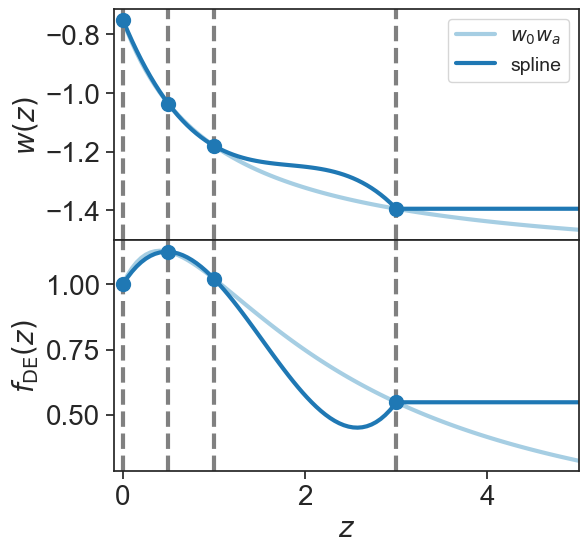

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})
ax[0].errorbar(z_i,  w_i_cpl,   marker='o',  markersize=10, linestyle='',color='C1')
ax[1].errorbar(z_i, fde_i_cpl,   marker='o',  markersize=10, linestyle='',color='C1')
ax[0].plot(zs, w0+wa*(zs/(1.+zs)), label='$w_0w_a$', color='C0')
ax[1].plot(zs, [fde_cpl(zs_i, w0, wa) for zs_i in zs], label='$w_0w_a$', color='C0')
ax[0].plot(zs, w_of_z(zs, z_i, w_i_cpl), label='spline', color='C1')
ax[1].plot(zs, fde_of_z(zs, z_i, fde_i_cpl),  color='C1')

    
for i in range(len(z_i)):
    ax[0].axvline(z_i[i], ls='--', color='grey')
    ax[1].axvline(z_i[i], ls='--', color='grey')
ax[1].set_xlabel('$z$')
ax[0].set_ylabel('$w(z)$')
ax[1].set_ylabel(r'$f_{\rm DE}(z)$')
ax[0].set_xlim(-0.1, 5)
ax[0].legend()
plt.show()

In [7]:
# The arguments of the Background functions follow the cosmology.API
cosmo_dict = {
    'H0': 67.0, 
    'Omega_cdm0': 0.27, 
    'Omega_b0': 0.049, 
    'Omega_k0': 0.0, 
    'ns': 0.96, 
    'As': 2.1e-9,
    'mnu': 0.077,
}
background_de_wz = DESplinedEoSBackground(cosmo_dict,
                            z_i = z_i,
                            w_i = w_i_cpl
                            )
background_de_fde = DESplinedDensityBackground(cosmo_dict,
                            z_i = z_i,
                            fde_i = fde_i_cpl
                            )


In [8]:
zs0 = np.array([0.])
print(background_cpl.Omega_m(zs0))
print(background_de_wz.Omega_m(zs0))
print(background_de_fde.Omega_m(zs0))


[0.32084357]
[0.32084164]
[0.32084164]


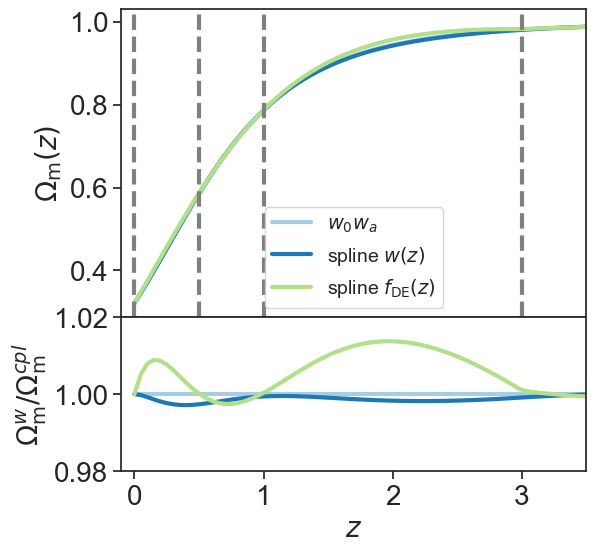

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.Omega_m(zs), label='spline $w(z)$', color='C1')
ax1.plot(zs, background_de_fde.Omega_m(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.Omega_m(zs)/background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.Omega_m(zs)/background_cpl.Omega_m(zs), label='spline $w(z)$', color='C1')
ax2.plot(zs, background_de_fde.Omega_m(zs)/background_cpl.Omega_m(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


for i in range(len(z_i)):
    ax1.axvline(z_i[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$\\Omega_{\\rm m}(z)$')
ax2.set_ylabel('$\\Omega^{w}_{\\rm m}/\\Omega^{cpl}_{\\rm m}$')
ax2.set_xlim(-0.1, 3.5)
ax2.set_ylim(0.98, 1.02)
ax1.legend()
plt.show()

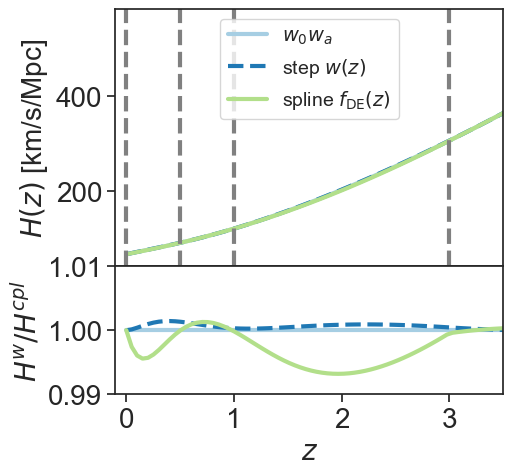

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.hubble_parameter(zs), label='step $w(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_de_fde.hubble_parameter(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='spline $w(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_de_fde.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


for i in range(len(z_i)):
    ax1.axvline(z_i[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$H(z)$ [km/s/Mpc]')
ax2.set_ylabel('$H^{w}/H^{cpl}$')
ax2.set_xlim(-0.1, 3.5)
ax2.set_ylim(0.99, 1.01)
ax1.legend()
plt.show()

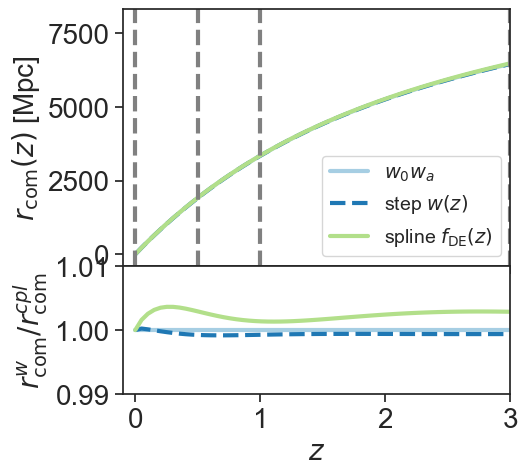

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.comoving_distance(zs), label='step $w(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_de_fde.comoving_distance(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='spline $w(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_de_fde.comoving_distance(zs)/background_cpl.comoving_distance(zs), label=r'spline $f_{\rm DE}(z)$', color='C2')


for i in range(len(z_i)):
    ax1.axvline(z_i[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$r_{\\rm com}(z)$ [Mpc]')
ax2.set_ylabel('$r_{\\rm com}^{w}/r_{\\rm com}^{cpl}$')
ax2.set_xlim(-0.1, 3)
ax2.set_ylim(0.99, 1.01)
ax1.legend()
plt.show()

# Perturbations: linear and nonlinear

In [12]:
linear_perturbations_lcdm = HMemuLinearPerturbations(background_lcdm, zs)
linear_perturbations_cpl = HMemuLinearPerturbations(background_cpl, zs)

log10_t_agn = 7.75

nonlinear_perturbations_lcdm = HMemuNonLinearPerturbations(background_lcdm, linear_perturbations_lcdm, zs, log10TAGN=log10_t_agn)
nonlinear_perturbations_cpl = HMemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl, zs, log10TAGN=log10_t_agn)

In [13]:
linear_perturbations_de_wz = DESplinedEoSLinearPerturbations(background_de_wz, linear_perturbations_lcdm)
linear_perturbations_de_fde = DESplinedDensityLinearPerturbations(background_de_fde, linear_perturbations_lcdm)
nonlinear_perturbations_de_wz = DESplinedEoSNonlinearPerturbations(background_de_wz, linear_perturbations_de_wz, zs, log10TAGN=log10_t_agn)
nonlinear_perturbations_de_fde = DESplinedDensityNonlinearPerturbations(background_de_fde, linear_perturbations_de_fde, zs, log10TAGN=log10_t_agn)

In [14]:
ks = np.logspace(np.log10(1e-3), np.log10(5), 100)
ps_lin_lcdm = linear_perturbations_lcdm.matter_power_spectrum(0, ks)
ps_lin_cpl = linear_perturbations_cpl.matter_power_spectrum(0, ks)
ps_lin_de_wz = linear_perturbations_de_wz.matter_power_spectrum(0, ks)
ps_lin_de_fde = linear_perturbations_de_fde.matter_power_spectrum(0, ks)
ps_nonlin_lcdm = nonlinear_perturbations_lcdm.matter_power_spectrum(0, ks)
start = time.time()
ps_nonlin_cpl = nonlinear_perturbations_cpl.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
start = time.time()
ps_nonlin_de_wz = nonlinear_perturbations_de_wz.matter_power_spectrum(0, ks)
ps_nonlin_de_fde = nonlinear_perturbations_de_fde.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
print(ps_nonlin_cpl.shape, ps_nonlin_de_wz.shape, ps_nonlin_de_fde.shape, ps_lin_cpl.shape, ps_lin_de_wz.shape, ps_lin_de_fde.shape)

3.910064697265625e-05
7.104873657226562e-05
(1, 100) (1, 100) (1, 100) (1, 100) (1, 100) (1, 100)


(0.97, 1.01)

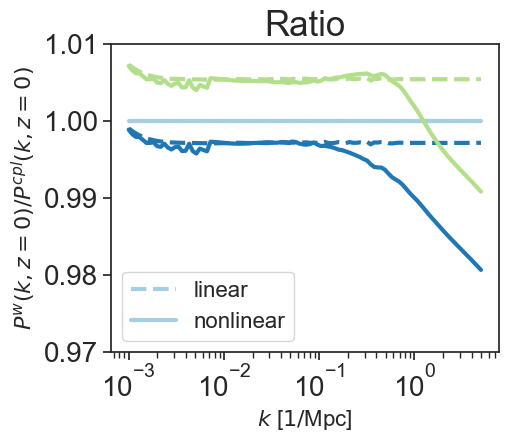

In [15]:
# Create the figure
plt.figure(figsize=(5, 4))

plt.semilogx(ks, ps_lin_cpl[0]/ps_lin_cpl[0], label='linear', color='C0', linestyle='--' )
plt.semilogx(ks, ps_nonlin_cpl[0]/ps_nonlin_cpl[0], label='nonlinear', color='C0' )
plt.semilogx(ks, ps_lin_de_wz[0]/ps_lin_cpl[0], color='C1' , linestyle='--')
plt.semilogx(ks, ps_nonlin_de_wz[0]/ps_nonlin_cpl[0], color='C1' )
plt.semilogx(ks, ps_lin_de_fde[0]/ps_lin_cpl[0], color='C2' , linestyle='--')
plt.semilogx(ks, ps_nonlin_de_fde[0]/ps_nonlin_cpl[0], color='C2' )

plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P^{w}(k, z=0)/P^{cpl}(k, z=0)$', fontsize = 16)

plt.legend(fontsize = 16)
plt.title("Ratio")
plt.ylim(0.97, 1.01)